# Applying Random Forest Linear Regression Model

Random Forest MSE: 0.0065
Random Forest R2 Score: 0.4448


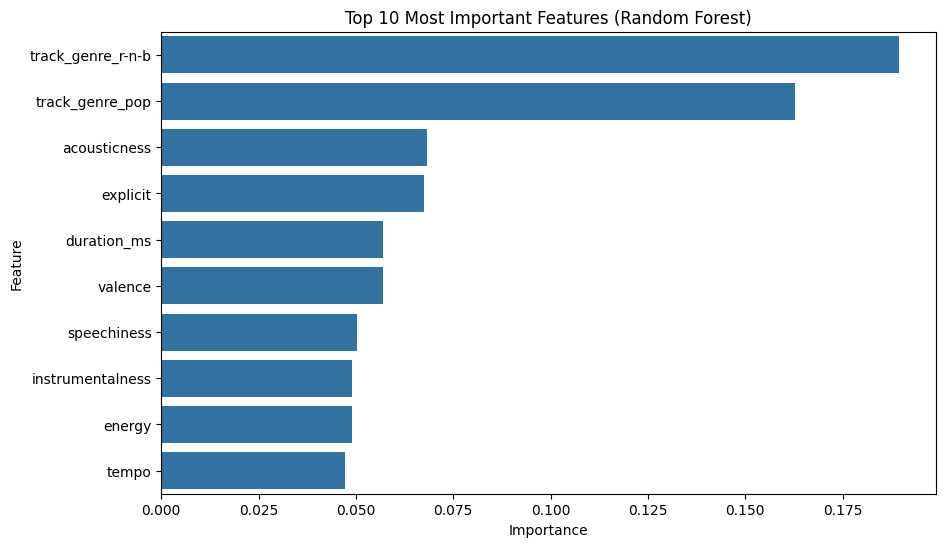

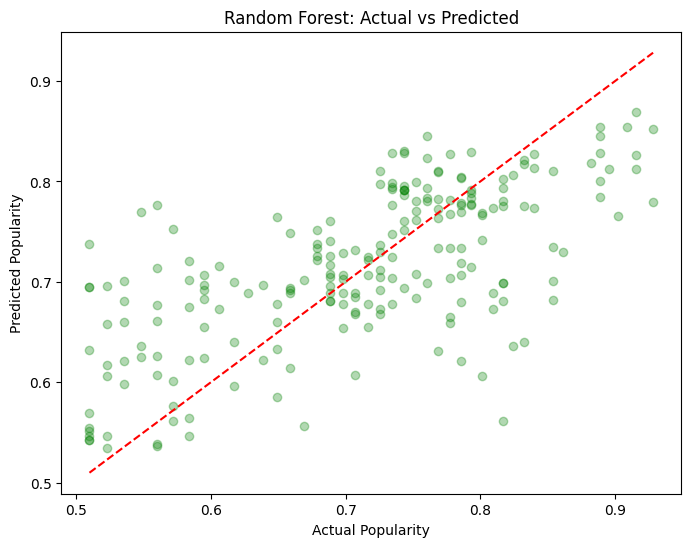

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the transformed dataset
# Ensure 'df_transformed.csv' is in the same directory as your notebook
df = pd.read_csv('df_filtered2.csv')

# 2. Define features (X) and target (y)
# We are predicting 'popularity' using all other available columns
target = 'popularity'
X = df.drop(columns=[target])
y = df[target]


# 1. Define features (X) and target (y)
target = 'popularity'
X = df.drop(columns=[target])
y = df[target]

# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and train the Random Forest
# n_estimators=100 means we are building 100 individual trees
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Make predictions
y_pred = rf_model.predict(X_test)

# 5. Evaluate
print(f"Random Forest MSE: {mean_squared_error(y_test, y_pred):.4f}")
print(f"Random Forest R2 Score: {r2_score(y_test, y_pred):.4f}")

# 6. Visualize Feature Importance
importances = rf_model.feature_importances_
feature_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df.head(10))
plt.title('Top 10 Most Important Features (Random Forest)')
plt.show()

# 7. Actual vs Predicted Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Popularity')
plt.ylabel('Predicted Popularity')
plt.title('Random Forest: Actual vs Predicted')
plt.show()